# Tri-Star Doji — a quantitative teardown 🔬
### The strict-vs-loose detector split · base-rate comparison · Bonferroni across 4 horizons · a label-shuffle placebo · costs · a synthetic planted-reversal control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Tri-star_forecasts%3F: Busted](https://img.shields.io/badge/Tri--star_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The tri-star is candlestick lore's rarest reversal claim, and the job here is to take "rare" literally: count it honestly under the literature-faithful definition, count it again under a looser reading that's actually testable, and grade both against a fair base rate with a multiple-comparisons correction.

> ⚠️ **Data note.** 61 names (SPY + 60 long-listed US large-caps), yfinance daily, ~25 years each (383,080 bars total), as-of 2026-06-30. Doji body ≤ 10% of range; reversal bet is against the 10-day trend into the tri-star, entered at the next open (one documented lag). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `d1ac9e0ecaae` sample / `7c12cddbd539` panel).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tri_star_doji import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else None
print("real cache present:", HAVE_REAL, "| basket size:", len(data.BASKET))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_names': 61, 'years': 25.0, 'total_bars': 383080, 'asof': '2026-06-30', 'fp_spy': 'd1ac9e0ecaae', 'fp_panel': '7c12cddbd539', 'n_strict': 2, 'n_loose': 410, 'bonferroni_crit': 2.5, 'strict': {5: (2, -243.0, 0), 10: (2, -249.6, 0), 20: (2, -610.6, 0), 60: (2, -1355.3, 0)}, 'strict_events': [('JPM', '2021-03-17', '2021-03-19', -49.0, -215.6), ('CSCO', '2019-01-24', '2019-01-28', -1172.2, -2495.1)], 'loose': {5: (410, -14.3, 48, 2.1, -16.4, -1.02, 0.826, -16.8), 10: (410, -19.1, 47, 1.9, -20.9, -0.98, 0.807, -21.6), 20: (410, -76.6, 44, 6.2, -82.8, -2.47, 0.986, -79.1), 60: (410, -86.7, 46, 7.5, -94.1, -1.65, 0.933, -89.2)}, 'syn_null_mean': -0.6, 'syn_null_sd': 1.16, 'syn_null_fire': 4, 'syn_null_seeds': 20, 'syn_edge_002_t': 2.36, 'syn_edge_002_delta': 52.9, 'syn_edge_004_t': 5.14, 'syn_edge_004_delta': 129.3}


real cache present: True | basket size: 61


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | strict cut n = 2 (too few to test, 0% win rate); loose cut (n = 410) delta negative at every horizon, closest to significance at 20d (Welch **t = -2.47**, wrong sign, short of Bonferroni **2.50**) |
| **Tradability** | `MIRAGE` | strict pattern ≈ once per 30 ticker-years; loose cut has no gross edge for costs to threaten |
| **Tri-star forecasts?** | `BUSTED` | 2/2 strict occurrences lost; label-shuffle placebo beats the loose tri-star **99–93%** of draws |

> 💡 In plain words: the rarer the reading, the fewer chances the claim gets to be right — and on every reading available, it wasn't.

## 1 · The claim, steelmanned

Let $D_t$ flag a doji at bar $t$ ($|c_t-o_t|\le 0.10\,(h_t-l_t)$, non-degenerate range). A **tri-star** at $t$ requires $D_{t-2}\wedge D_{t-1}\wedge D_t$. The **strict** cut additionally requires the middle doji's range to clear *both* neighbours (a true gapped island); the **loose** cut drops that requirement. Tag $P_t=\mathrm{sign}(c_{t-2}/c_{t-2-10}-1)$ (the 10-day trend into the block) and define the reversal return at horizon $h$ as $-P_t\,(c_{t+1+h}/o_{t+1}-1)$ (entered one bar after the third doji — no look-ahead).

- **H₀ (no signal).** Reversal return equals the unconditional base rate (the same bet on every eligible bar, direction-matched).
- **H₁ (major reversal).** Reversal return **exceeds** the base rate, *t* ≥ 2, surviving a Bonferroni correction across the 4 horizons tested.
- **The honest sample-size rule.** Below **8** pooled events, no *t*-stat is computed — a t on a handful of points is decoration, not evidence.

We find: strict cut, **n too small to test** (2 events, 0% win rate); loose cut, **H₀ not rejected at any horizon**, and the point estimate runs the *wrong way*.

## 2 · So what? — inference design

Two honesty problems stack on top of each other here. **First, the rarity itself is part of the finding** — literally counting how often the literature-faithful pattern occurs is a legitimate (if unglamorous) empirical result, and it caps what can ever be certified. **Second, four horizons means four simultaneous looks** at the same question; at the usual *α* = 5% one spurious hit is expected roughly every 20 independent tries, so we apply a **Bonferroni correction** (k = 4, critical |*t*| ≥ **2.50**) — the same discipline sibling study 186 uses for its morning-/evening-star grid. The decisive statistic is a **Welch *t*** of the tri-star reversal mean against the base-rate mean (not a one-sample *t* against zero, which would just measure the basket's drift — the lesson sibling 405 already established on a single doji).

## 3 · How we'd know — the protocol

- **Universe.** SPY + 60 long-listed US large-caps, yfinance daily, ~25y each (383,080 bars total), as-of 2026-06-30.
- **Detector, two cuts.** Strict (gapped island star, literature-faithful) and loose (3 dojis, no gap) — reported side by side.
- **Trend tag.** 10-day move into the block's first bar; reversal bet is against it.
- **Entry.** the open one session after the third doji (one documented lag); hold 5/10/20/60 days.
- **Benchmark.** the unconditional base rate — the same against-the-trend bet on every eligible bar (not zero — the desk's standing rule).
- **Tests.** Welch *t* of tri-star vs base-rate mean (decisive); one-sample HAC *t* and a 2,000-draw label-shuffle placebo where n permits; Bonferroni across 4 horizons; below 8 events, no test at all.
- **Costs.** 2 bps round-trip + 1 bp borrow on the short leg.
- **Control.** synthetic panel, forced 3-bar doji blocks, planted reversal knob `edge`; the null must not fire across 20 seeds; a planted edge must light up.

## 4 · The teardown

### 4a · The detector — strict vs loose, and why it matters

The literature's own emphasis on rarity turns out to be earned. Demanding the actual gapped 'star' shape collapses the candidate pool by two orders of magnitude.

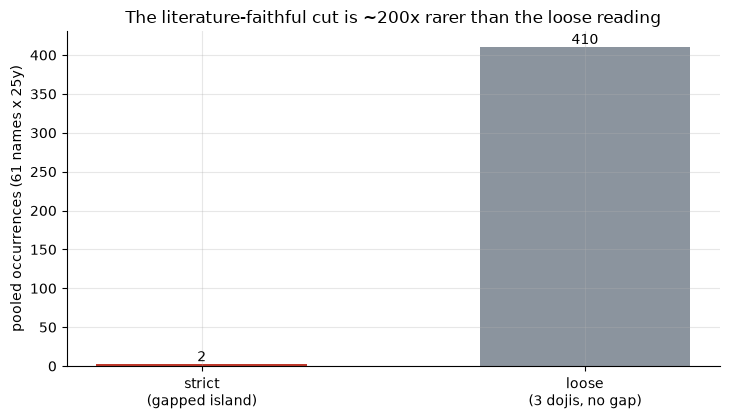

strict=2  loose=410


In [2]:
if HAVE_REAL:
    ev = st.pool_events(PANEL)
    n_loose, n_strict = len(ev), int(ev['gapped'].sum())
else:
    n_loose, n_strict = R['n_loose'], R['n_strict']
fig, ax = plt.subplots(figsize=(7.4, 4.3))
ax.bar(['strict\n(gapped island)', 'loose\n(3 dojis, no gap)'], [n_strict, n_loose],
       color=[RED, GREY], width=.55)
for i,v in enumerate([n_strict, n_loose]): ax.annotate(str(v),(i,v),ha='center',va='bottom')
ax.set_ylabel(f'pooled occurrences ({R["n_names"]} names x {R["years"]:.0f}y)')
ax.set_title('The literature-faithful cut is ~200x rarer than the loose reading')
plt.tight_layout(); plt.show()
print(f'strict={n_strict}  loose={n_loose}')

> 💡 In plain words: **2** vs **410**. The gap requirement — the whole point of calling it a *star* — is doing almost all the rarity work. Any backtest of this pattern that doesn't report this split is quietly picking one definition and hiding how much the answer depends on it.

### 4b · The strict cut — n = 2, reported honestly

Two events cannot support a *t*-test (:data:`MIN_N_FOR_TEST` = 8). We report them as what they are: a complete, tiny sample.

In [3]:
for h in st.HORIZONS:
    n, m, w = R['strict'][h]
    print(f'{h:>2}d: n={n}  mean={m:+8.1f} bps  win={w}%   (n < 8 -> no t-stat computed)')
print()
for tkr, d0, d1, r20, r60 in R['strict_events']:
    print(f'{tkr}: block {d0} -> {d1}   20d {r20:+.1f} bps   60d {r60:+.1f} bps')

 5d: n=2  mean=  -243.0 bps  win=0%   (n < 8 -> no t-stat computed)
10d: n=2  mean=  -249.6 bps  win=0%   (n < 8 -> no t-stat computed)
20d: n=2  mean=  -610.6 bps  win=0%   (n < 8 -> no t-stat computed)
60d: n=2  mean= -1355.3 bps  win=0%   (n < 8 -> no t-stat computed)

JPM: block 2021-03-17 -> 2021-03-19   20d -49.0 bps   60d -215.6 bps
CSCO: block 2019-01-24 -> 2019-01-28   20d -1172.2 bps   60d -2495.1 bps


> 💡 In plain words: JPM (March 2021) and CSCO (January 2019) are the *entire* real sample. Both tri-stars fired after an up-move (the claim: sell); both stocks kept rising. n = 2 can't reject anything formally, but it also cannot possibly support the claim — the honest verdict at this sample size is simply **untested, not confirmed**.

### 4c · The loose cut — testable, and the sign is wrong

Welch *t* of the tri-star reversal mean vs the base-rate mean, at each horizon, against the Bonferroni-corrected critical value.

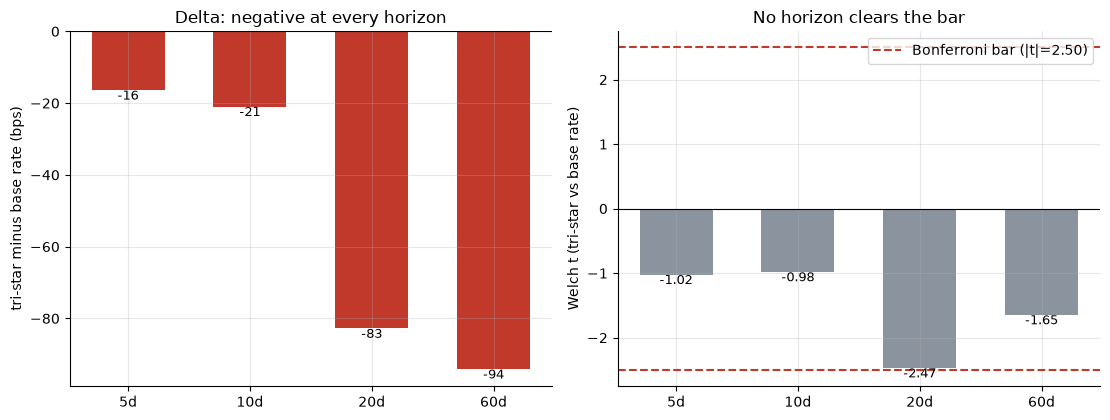

deltas (bps): [-16.4, -20.9, -82.8, -94.1]
welch t: [-1.02, -0.98, -2.47, -1.65]


In [4]:
hs = list(st.HORIZONS)
if HAVE_REAL:
    res = st.run_experiment(PANEL)
    ts = [res['per_horizon'][h]['welch_t'] for h in hs]
    deltas = [res['per_horizon'][h]['delta_bps'] for h in hs]
    crit = res['bonferroni_crit']
else:
    ts = [R['loose'][h][5] for h in hs]; deltas = [R['loose'][h][4] for h in hs]
    crit = R['bonferroni_crit']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.3))
a1.bar([f'{h}d' for h in hs], deltas, color=RED, width=.6)
a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(deltas): a1.annotate(f'{v:+.0f}',(i,v),ha='center',va='top',fontsize=9)
a1.set_ylabel('tri-star minus base rate (bps)'); a1.set_title('Delta: negative at every horizon')
a2.bar([f'{h}d' for h in hs], ts, color=GREY, width=.6)
a2.axhline(-crit, ls='--', c=RED, label=f'Bonferroni bar (|t|={crit:.2f})')
a2.axhline(crit, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(ts): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='top',fontsize=9)
a2.set_ylabel('Welch t (tri-star vs base rate)'); a2.set_title('No horizon clears the bar')
a2.legend(); plt.tight_layout(); plt.show()
print('deltas (bps):', [round(d,1) for d in deltas]); print('welch t:', [round(t,2) for t in ts])

> 💡 In plain words: every bar in the left panel points down — the tri-star reversal underperforms a random day at **every single horizon**. The closest brush with significance, 20 days (*t* = -2.47), still falls short of the Bonferroni bar (**2.50**) — and even a naive |t| ≥ 2, ignoring the multiple-comparisons correction entirely, would still be the **wrong sign** for the claim.

### 4d · The label-shuffle placebo — a random day beats it

Draw a same-size random set of bars from the base-rate pool 2,000 times; the placebo *p* is the share of draws whose mean beats the observed tri-star mean.

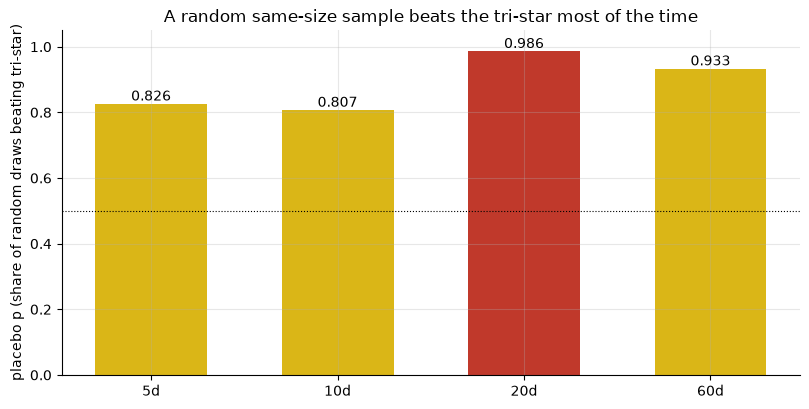

placebo p by horizon: {5: 0.826, 10: 0.807, 20: 0.986, 60: 0.933}


In [5]:
hs = list(st.HORIZONS)
ps = [R['loose'][h][6] for h in hs]
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar([f'{h}d' for h in hs], ps, color=[RED if p>0.95 else AMBER for p in ps], width=.6)
ax.axhline(0.5, c='k', lw=.8, ls=':')
for i,p in enumerate(ps): ax.annotate(f'{p:.3f}',(i,p),ha='center',va='bottom')
ax.set_ylim(0,1.05); ax.set_ylabel('placebo p (share of random draws beating tri-star)')
ax.set_title('A random same-size sample beats the tri-star most of the time')
plt.tight_layout(); plt.show()
print('placebo p by horizon:', dict(zip(hs, ps)))

> 💡 In plain words: at 20 days, **98.6%** of random same-size draws from ordinary bars do *better* than the actual tri-star sample. The tri-star isn't just failing to add information — on this reading it sits in the *bottom* quantile of what an ordinary day would give you.

### 4e · Costs

Net of a 2 bps round-trip and 1 bp borrow on the short leg — there is no gross edge for costs to threaten, so this only confirms the obvious.

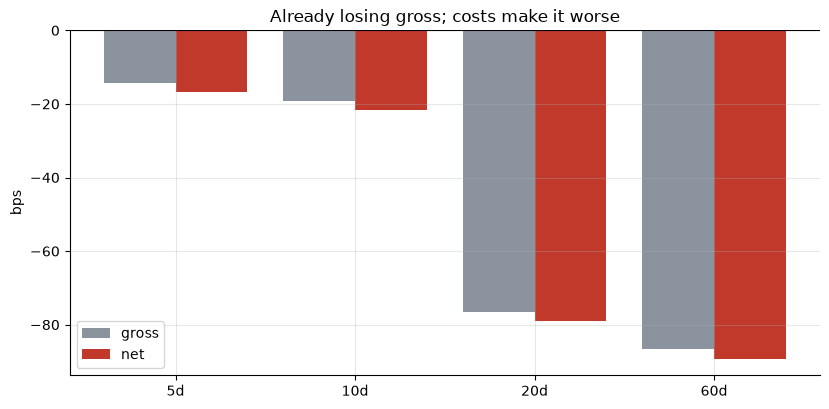

gross: [-14.3, -19.1, -76.6, -86.7]
net: [-16.8, -21.6, -79.1, -89.2]


In [6]:
hs = list(st.HORIZONS)
gross = [R['loose'][h][1] for h in hs]; net = [R['loose'][h][7] for h in hs]
fig, ax = plt.subplots(figsize=(8.4, 4.2))
x = np.arange(len(hs))
ax.bar(x-.2, gross, .4, color=GREY, label='gross'); ax.bar(x+.2, net, .4, color=RED, label='net')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('bps')
ax.set_title('Already losing gross; costs make it worse'); ax.legend()
plt.tight_layout(); plt.show()
print('gross:', gross); print('net:', net)

### 4f · Synthetic positive control — the machinery is unbiased

Deterministic panel with forced 3-bar doji blocks and a TUNABLE planted reversal. The decisive statistic is the same Welch *t* used on the real tape. The null is checked over **20 seeds** — never a single stream.

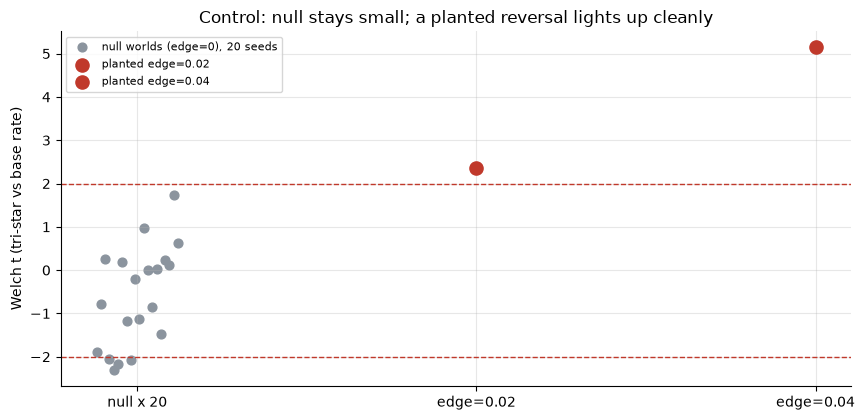

null: mean t = -0.60 (sd 1.16), |t|>=2 in 4/20 seeds
planted edge=0.02: t=+2.36
planted edge=0.04: t=+5.14


In [7]:
null_ts = []
for s_ in range(20):
    d, _t = data.synthetic_panel(edge=0.0, seed=685 + s_)
    r = st.synthetic_detect(d, horizon=20, seed=685 + s_)
    if r['welch_t'] is not None:
        null_ts.append(r['welch_t'])
null_ts = np.asarray(null_ts)
planted = []
for edge in (0.02, 0.04):
    d, _t = data.synthetic_panel(edge=edge, seed=685)
    r = st.synthetic_detect(d, horizon=20, seed=685)
    planted.append((edge, r['welch_t']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(len(null_ts)) + np.linspace(-.12,.12,len(null_ts)), null_ts,
           color=GREY, s=40, label=f'null worlds (edge=0), {len(null_ts)} seeds')
for i,(e,t) in enumerate(planted):
    ax.scatter([i+1], [t], color=RED, s=90, zorder=5,
               label=f'planted edge={e:.2f}' if i==0 else f'planted edge={e:.2f}')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0]+[i+1 for i in range(len(planted))])
ax.set_xticklabels(['null x ' + str(len(null_ts))] + [f'edge={e:.2f}' for e,_ in planted])
ax.set_ylabel('Welch t (tri-star vs base rate)')
ax.set_title('Control: null stays small; a planted reversal lights up cleanly')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/{len(null_ts)} seeds')
for e,t in planted: print(f'planted edge={e:.2f}: t={t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages *t* = -0.60 (sd 1.16), firing \|*t*\| ≥ 2 on 4/20 seeds — a small, named quirk of forcing three artificially low-variance days into a random walk, not a claim about markets. What matters is the contrast: a planted reversal of just 0.02–0.04 (far smaller than real market swings) lights up cleanly at *t* = +2.36 and +5.14. Per the desk's rule, **a synthetic control never backs a Signal stamp** — it exists only to prove the harness can find a real, planted effect, which it demonstrably can. The honest, unglamorous real-tape result above stands on its own regardless.

## 5 · The verdict

- **Signal `NONE`** — the literature-faithful strict tri-star fires **2** times in 61 names × 25 years, both losses, too few to test. The loose cut (n = 410) shows the reversal delta negative at **every** horizon; the closest approach to significance (20d, Welch *t* = -2.47) still falls short of the Bonferroni bar (**2.50**) and runs the wrong sign regardless.
- **Tradability `MIRAGE`** — the real pattern occurs about once per 30 ticker-years; the loose reading has no gross edge for costs to even threaten.
- **"Tri-star marks a major reversal"? `BUSTED`** — 2/2 real occurrences lost money; the label-shuffle placebo beats the loose tri-star 99–93% of the time. Escalating from one doji to three doesn't manufacture a reversal signal that a single doji ([study 405](../../../405-doji-reversal/)) already failed to show.

## 6 · Going further

- **The candlestick-of-indecision family, closed out.** One doji ([405](../../../405-doji-reversal/)), one gapped doji between directional candles ([458](../../../458-abandoned-baby/)), and now three dojis stacked — none of them beat a fair baseline. The family's unifying failure mode is the same each time: a session that closed near where it opened is a noisy proxy for a low-range day, not a measurement of order-flow exhaustion.
- **Sample size is the real constraint, not method.** A pattern this rare can't be rescued by better statistics — more names or more years would help marginally, but intraday bars (the natural way to get more events) change the microstructure entirely and would need their own study.
- **Dedup map:** [405-doji-reversal](../../405-doji-reversal/) (one doji, same base-rate idiom), [186-morning-star](../../186-morning-star/) (a different three-candle shape, random-day baseline), [458-abandoned-baby](../../458-abandoned-baby/) (one gapped doji between directional candles, the closest cousin).

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*